# Analyzing Boston Weather Data from 2013 and 2022

By Emma Bowen

## Introduction

This Python project focuses on how the average max air temperature (°C) and precipitation (mm) vary in March in Boston in 2013 and 2022. Historically, March has been one of the rainiest months in Boston, and analyzing weather data from almost 10 years apart can yield insights into potential climate change ("Boston (MA) Monthly Rainfall", 2026).

This project was reformatted from my original Python script structure to present my code and findings in a notebook for cleaner analysis and visualization. 

## Material and Methods

This project utilizes Python and was developed from a Python script to a Jupyter Notebook. The Python packages: `pandas`, `seaborn`, and `matplotlib` were used.\
The dataset for the project, *Boston Weather 2013-2023*, originated from Kaggle and was published by Meher 2023. The data is CC0: Public Domain.

## Data Analysis

In [108]:
# Import Python packages needed for analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [116]:
def import_data():
    """This function imports the CSV file into a pandas DataFrame."""
    boston_data = pd.read_csv("boston_weather_data.csv")
    return boston_data
def clean_data(boston_data):
    """Remove any 'NA' and duplicate values from the data."""
    boston_data = boston_data.dropna()
    boston_data = boston_data.drop_duplicates()
    return boston_data
def boston_summary(boston_data):
    """Return summary statistics of the cleaned pandas DataFrame"""
    boston_data_summary = boston_data.describe()
    return boston_data_summary
def date_time(boston_data):
    """Convert the column 'time' currently holding strings into standard pandas DateTime"""
    boston_data['time'] = pd.to_datetime(boston_data['time'])
    return boston_data
def year_time(boston_data):
    """Extract the year saved as a new column from the DateTime column"""
    boston_data['year'] = boston_data['time'].dt.year
    return boston_data
def month_time(boston_data):
    """Extract the month saved as a new column from the DateTime column"""
    boston_data['month'] = boston_data['time'].dt.month
    return boston_data
def day_time(boston_data):
    """Extract the day saved as a new column from the DateTime column"""
    boston_data['day'] = boston_data['time'].dt.day
    return boston_data
def old_march(boston_data):
    """Create a new variable that filters the data to only contain the year '2013' and month '3'"""
    old_march_boston = boston_data[((boston_data["year"] == 2013) & (boston_data["month"] == 3))]
    return old_march_boston
def new_march(boston_data):
    """Create a new variable that filters the data to only contain the year '2022' and month '3'"""
    new_march_boston = boston_data[((boston_data["year"] == 2022) & (boston_data["month"] == 3))]
    return new_march_boston
def old_tavg(old_march_boston):
    """This function calculates the average max air temperature of the 
      filtered variable 'old_march_boston'"""
    old_tavg_march = round(old_march_boston['tmax'].mean(),2)
    return old_tavg_march
def old_prcp(old_march_boston):
    """This function calculates the average precipitation of the 
    filtered variable 'old_march_boston'"""
    old_prcp_march = round(old_march_boston['prcp'].mean(),2)
    return old_prcp_march
def new_tavg(new_march_boston):
    """This function calculates the average max air temperature of the 
    filtered variable 'new_march_boston'"""
    new_tavg_march = round(new_march_boston['tmax'].mean(),2)
    return new_tavg_march
def new_prcp(new_march_boston):
    """This function calculates the average precipitation of the 
    filtered variable 'new_march_boston'"""
    new_prcp_march = round(new_march_boston['prcp'].mean(),2)
    return new_prcp_march
def combined_new_old(old_march_boston, new_march_boston):
    """This function uses pandas to combine both 'old_march_boston' and 
    'new_march_boston' into a single, new column"""
    old_new_march = pd.concat([old_march_boston, new_march_boston])
    return old_new_march
def prcp_plot(old_new_march):
    """This function plots the precipitation (mm) of
    each day in March in 2013 versus 2022 using seaborn and matplotlib"""
    plt.figure()
    sns.lineplot(data=old_new_march, x="day", y= "prcp", hue = "year", palette="Set2")
    plt.xlabel("Days in March")
    plt.ylabel("Precipitation (mm)")
    plt.title("Comparing Boston's precipitation (mm) in March 2013 versus March 2022")
    plt.savefig("precipitation_march.png")
def temp_plot(old_new_march):
    """This function plots the average max air temperature (°C)
    each day in March in 2013 versus 2022 using seaborn and matplotlib"""
    plt.figure()
    sns.lineplot(data=old_new_march, x="day", y= "tavg", hue = "year", palette="Set1")
    plt.xlabel("Days in March")
    plt.ylabel("Average Max Air Temperature (°C)")
    plt.title("Comparing Boston's average max air temperature (°C) in March 2013 versus March 2022", fontsize=10)
    plt.savefig("temperature_march.png")

## Data Pipeline and Results

In [117]:
# 1. Import the CSV file
# 2. Clean the data to remove NA and duplicate values
# 3. Print summary statistics of the data
# 4. Convert the time column and extract years, months, and days
# 5. Filter and save only March weather in 2013 as a new variable
# 6. Filter and save only March weather in 2022 as a new variable
# 7. Calculate average temperature and precipitation for filtered data and print the results
# 8. Compare the averages from 2013 and 2022 by plotting the results

Summary Statistics of the cleaned data:
              tavg         tmin         tmax         prcp         wdir  \
count  2978.000000  2978.000000  2978.000000  2978.000000  2978.000000   
mean     11.496273     7.414137    15.775756     2.745601   201.110477   
std       9.643193     9.484964    10.321128     7.232285    99.807586   
min     -17.800000   -23.300000   -12.100000     0.000000     0.000000   
25%       3.900000     0.600000     7.200000     0.000000   113.000000   
50%      11.100000     7.200000    15.600000     0.000000   227.000000   
75%      20.000000    15.600000    24.400000     1.300000   279.000000   
max      32.300000    28.300000    37.800000    78.000000   360.000000   

              wspd         pres  
count  2978.000000  2978.000000  
mean     18.279080  1016.274580  
std       5.936124     7.795303  
min       2.500000   983.900000  
25%      14.100000  1011.200000  
50%      17.300000  1016.200000  
75%      21.600000  1021.375000  
max      61.200000  1

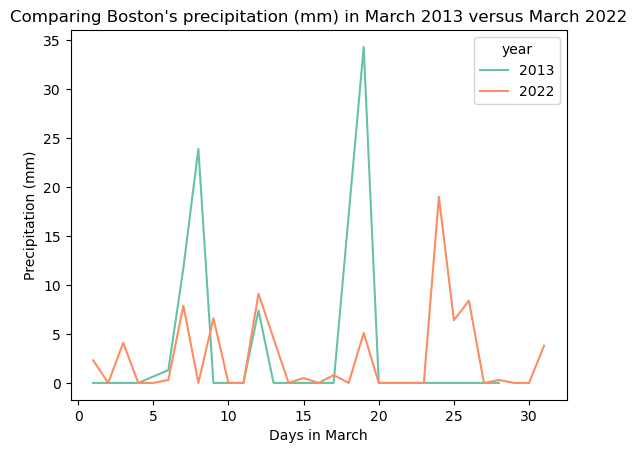

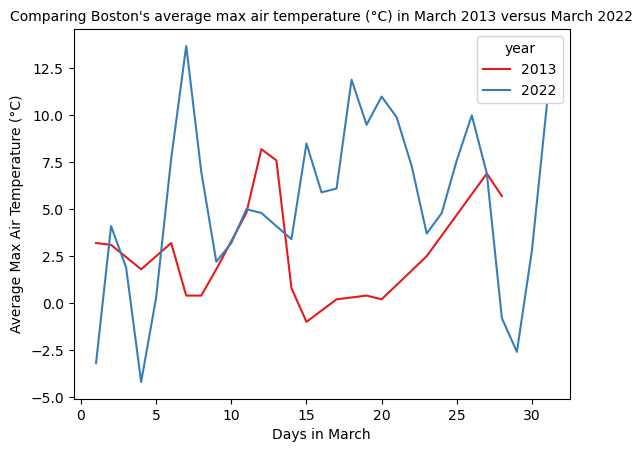

In [118]:
boston_data = import_data()
boston_data = clean_data(boston_data)
boston_data_summary = boston_summary(boston_data)
print("Summary Statistics of the cleaned data:")
print(boston_data_summary)
boston_data = date_time(boston_data)
boston_data = year_time(boston_data)
boston_data = month_time(boston_data)
boston_data = day_time(boston_data)
old_march_boston = old_march(boston_data)
new_march_boston = new_march(boston_data)
old_tavg_march = old_tavg(old_march_boston)
old_prcp_march = old_prcp(old_march_boston)
new_tavg_march = new_tavg(new_march_boston)
new_prcp_march = new_prcp(new_march_boston)
print(f"In March 2013, Boston's average max air temperature was {old_tavg_march}°C, with an average precipitation of {old_prcp_march} mm.")
print(f"In March 2022, Boston's average max air temperature was {new_tavg_march}°C, with an average precipitation of {new_prcp_march} mm.")
old_new_march = combined_new_old(old_march_boston, new_march_boston)
prcp_plot(old_new_march)
temp_plot(old_new_march)

## Discussion
Based on the computed results, it can be concluded that in March 2013, Boston averaged a lower maximum air temperature and greater precipitation (mm) than in March 2022, which had both a warmer average maximum air temperature and lower precipitation (mm).   
While more research would be needed to study weather patterns within this region, these results raise the question of how climate change has affected areas that historically received more rain and colder weather, as the almost 10-year difference reflects significant changes, including increased average maximum temperatures and decreased average precipitation.

## References

*Boston (MA) Monthly Rainfall & Precipitation*. (2026). Weather and Climate. https://weather-and-climate.com/average-monthly-precipitation-Rainfall,Boston,United-States-of-America  
Meher, S. (2023). *Boston Weather 2013-2023*. Kaggle. https://www.kaggle.com/datasets/swaroopmeher/boston-weather-2013-2023